<a href="https://colab.research.google.com/github/samay35/HCL_TRAINING/blob/main/loan_defaulters(HCL_1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import svm

In [ ]:
df = pd.read_csv("/content/loan_dataset (1).csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
df["ApplicantIncome"] = pd.to_numeric(df["ApplicantIncome"], errors="coerce")

df["LoanAmount"] = pd.to_numeric(df["LoanAmount"], errors="coerce")

# Also convert Loan_Amount_Term and Credit_History, which seem numeric
df["Loan_Amount_Term"] = pd.to_numeric(df["Loan_Amount_Term"], errors="coerce")
df["Credit_History"] = pd.to_numeric(df["Credit_History"], errors="coerce")

# The columns 'late_payment', 'debt_to_income', 'application_date' from the previous dataset
# are not present in the current 'loan_dataset (1).csv' and thus are removed.

In [ ]:
df.shape

(614, 13)

In [ ]:
df.replace({"Loan_Status":{'N':0,'Y':1}},inplace=True)

/tmp/ipykernel_2091/3434708264.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"Loan_Status":{'N':0,'Y':1}},inplace=True)


In [ ]:
df["Dependents"].value_counts( )


,count
Dependents,
0,345
1,102
2,101
3+,51


In [ ]:
df.replace({"Dependents":{'3+':4}},inplace=True)

In [ ]:
df["Dependents"].value_counts()

,count
Dependents,
0,345
1,102
2,101
4,51


<Axes: xlabel='Education', ylabel='count'>

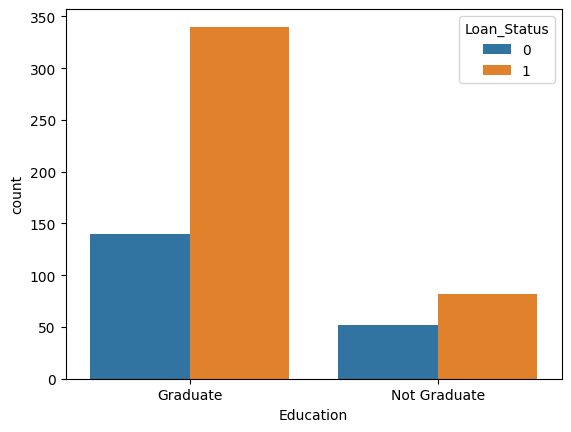

In [ ]:
# eductaion and loan status
sns.countplot(x="Education",hue="Loan_Status",data=df)

<Axes: xlabel='Married', ylabel='count'>

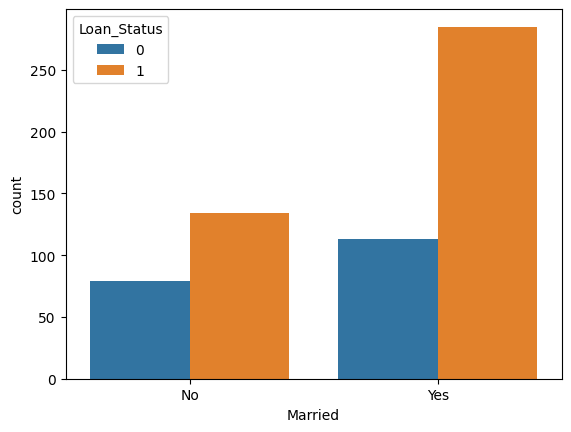

In [ ]:
sns.countplot(x="Married",hue="Loan_Status",data=df)

In [ ]:
# actually over model will not understand categorical data properly so we have to replace all  catagroical values to numerical values here


In [ ]:
df.replace({"Gender":{"Male":1,"Female":0},"Married":{"No":0,"Yes":1},"Education":{"Graduate":1,"Not Graduate":0},"Self_Employed":{"No":0,"Yes":1},"Property_Area":{"Urban":2,"Rural":0,"Semiurban":1}}, inplace=True)

/tmp/ipykernel_2091/2075538691.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"Gender":{"Male":1,"Female":0},"Married":{"No":0,"Yes":1},"Education":{"Graduate":1,"Not Graduate":0},"Self_Employed":{"No":0,"Yes":1},"Property_Area":{"Urban":2,"Rural":0,"Semiurban":1}}, inplace=True)


In [ ]:
df.head(n=20)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,1.0,1.0,1,1,0.0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1.0,1.0,0,1,1.0,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1.0,1.0,0,0,0.0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1.0,0.0,0,1,0.0,6000,0.0,141.0,360.0,1.0,2,1
5,LP001011,1.0,1.0,2,1,1.0,5417,4196.0,267.0,360.0,1.0,2,1
6,LP001013,1.0,1.0,0,0,0.0,2333,1516.0,95.0,360.0,1.0,2,1
7,LP001014,1.0,1.0,4,1,0.0,3036,2504.0,158.0,360.0,0.0,1,0
8,LP001018,1.0,1.0,2,1,0.0,4006,1526.0,168.0,360.0,1.0,2,1
9,LP001020,1.0,1.0,1,1,0.0,12841,10968.0,349.0,360.0,1.0,1,0
10,LP001024,1.0,1.0,2,1,0.0,3200,700.0,70.0,360.0,1.0,2,1


In [ ]:
df.dropna(inplace=True)
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [ ]:
x=df.drop(columns=["Loan_ID","Loan_Status"],axis=1)
y=df["Loan_Status"]

In [ ]:
X_train,x_test,Y_train,Y_test=train_test_split(x,y,test_size=0.1,random_state=2,stratify=y)

In [ ]:
model=svm.SVC(kernel="linear")
model.fit(X_train,Y_train)

SVC(kernel='linear')

In [ ]:
X_train_prediction=model.predict(X_train)
X_train_accuracy=accuracy_score(Y_train,X_train_prediction)
print("x_train_accuracy",X_train_accuracy)

x_train_accuracy 0.7986111111111112


In [ ]:
X_test_prediction=model.predict(x_test)
X_test_accuracy=accuracy_score(Y_test,X_test_prediction)
print("x_test_accuracy",X_test_accuracy)

x_test_accuracy 0.8333333333333334


In [ ]:
input_data=np.asarray([1, 0, 0, 1, 0, 6000, 0, 141, 360, 1, 2]).reshape(1,-1)
print(model.predict(input_data))

[1]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
